# CIELAB Color Distribution

Visualizes the distribution of extracted lipstick colors across the CIELAB color space.

- **a\*–b\* scatter**: chromatic plane: warm/cool and pink/orange/brown axes
- **L\* distribution**: lightness spread across the dataset
- **Facet by format**: whether swatch / bullet / liquid / other cluster differently
- **Color group centroids**: the 25 GMM groups overlaid on the scatter

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [18]:
CSV = Path('../data/processed/products_pipeline.csv')
df  = pd.read_csv(CSV)

# Drop rows with missing LAB values
df = df.dropna(subset=['L', 'a', 'b', 'hex_color']).copy()

# Normalize hex to lowercase with leading #
df['hex_color'] = df['hex_color'].str.strip().str.lower()
df['hex_color'] = df['hex_color'].apply(lambda x: x if x.startswith('#') else f'#{x}')
df['group_hex'] = df['group_hex'].str.strip().str.lower()
df['group_hex'] = df['group_hex'].apply(lambda x: x if x.startswith('#') else f'#{x}')

print(f'{len(df):,} products loaded')
print(f'pred_label counts:\n{df["pred_label"].value_counts()}')

9,167 products loaded
pred_label counts:
pred_label
swatch             3834
bullet_lipstick    3712
liquid_lipstick    1507
other               114
Name: count, dtype: int64


## a\*–b\* scatter: full dataset

Each point is one product shade, colored by its extracted hex. The a\* axis runs green (–) to red/pink (+); b\* runs blue (–) to yellow/orange (+). Most lipstick shades cluster in the warm positive quadrant.

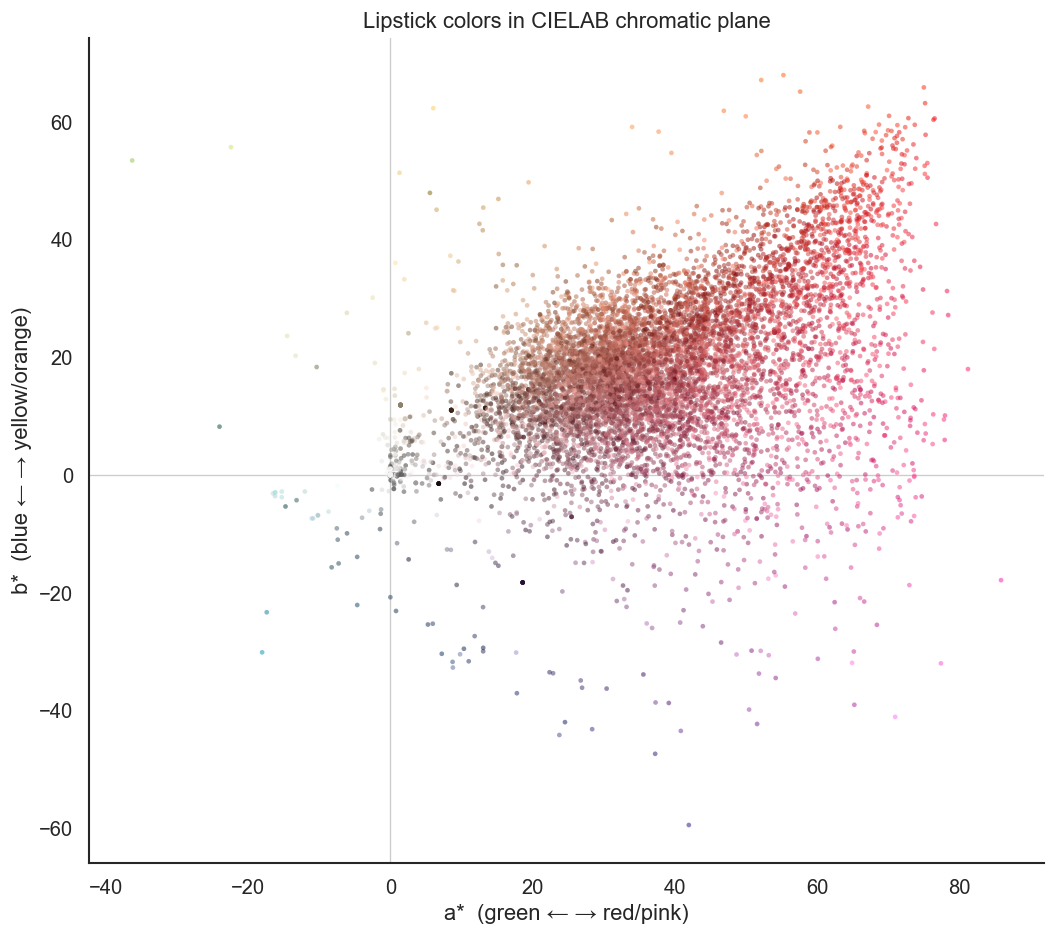

In [19]:
fig, ax = plt.subplots(figsize=(9, 8))

ax.scatter(
    df['a'], df['b'],
    c=df['hex_color'],
    s=8, alpha=0.5, linewidths=0
)

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('Lipstick colors in CIELAB chromatic plane')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## L\* distribution

Lightness across the full dataset. Lipsticks typically range from deep plums (L~20) to pale nudes (L~80).

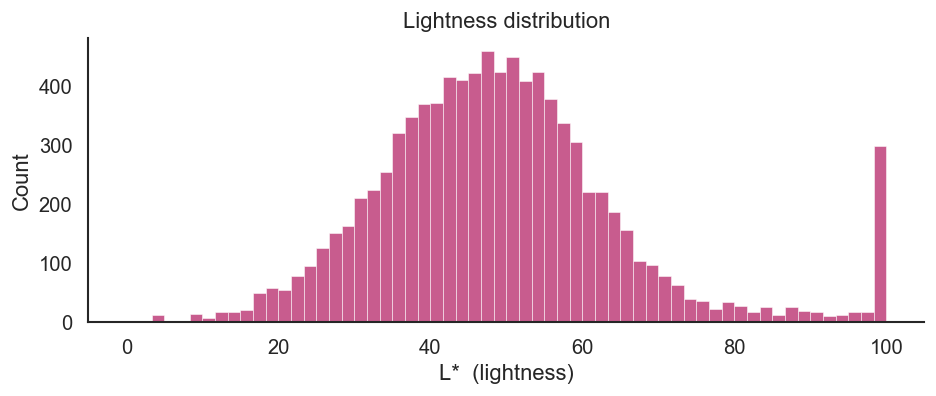

count    9167.0
mean       49.3
std        16.8
min         0.0
25%        38.7
50%        48.0
75%        57.2
max       100.0
Name: L, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.hist(df['L'], bins=60, color='#c85c8e', edgecolor='white', linewidth=0.3)
ax.set_xlabel('L*  (lightness)')
ax.set_ylabel('Count')
ax.set_title('Lightness distribution')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(df['L'].describe().round(1))

## a\*–b\* scatter: faceted by format

Checks whether different product formats (swatch, bullet, liquid, other) land in different parts of the chromatic plane: which would suggest extraction bias rather than actual color differences.

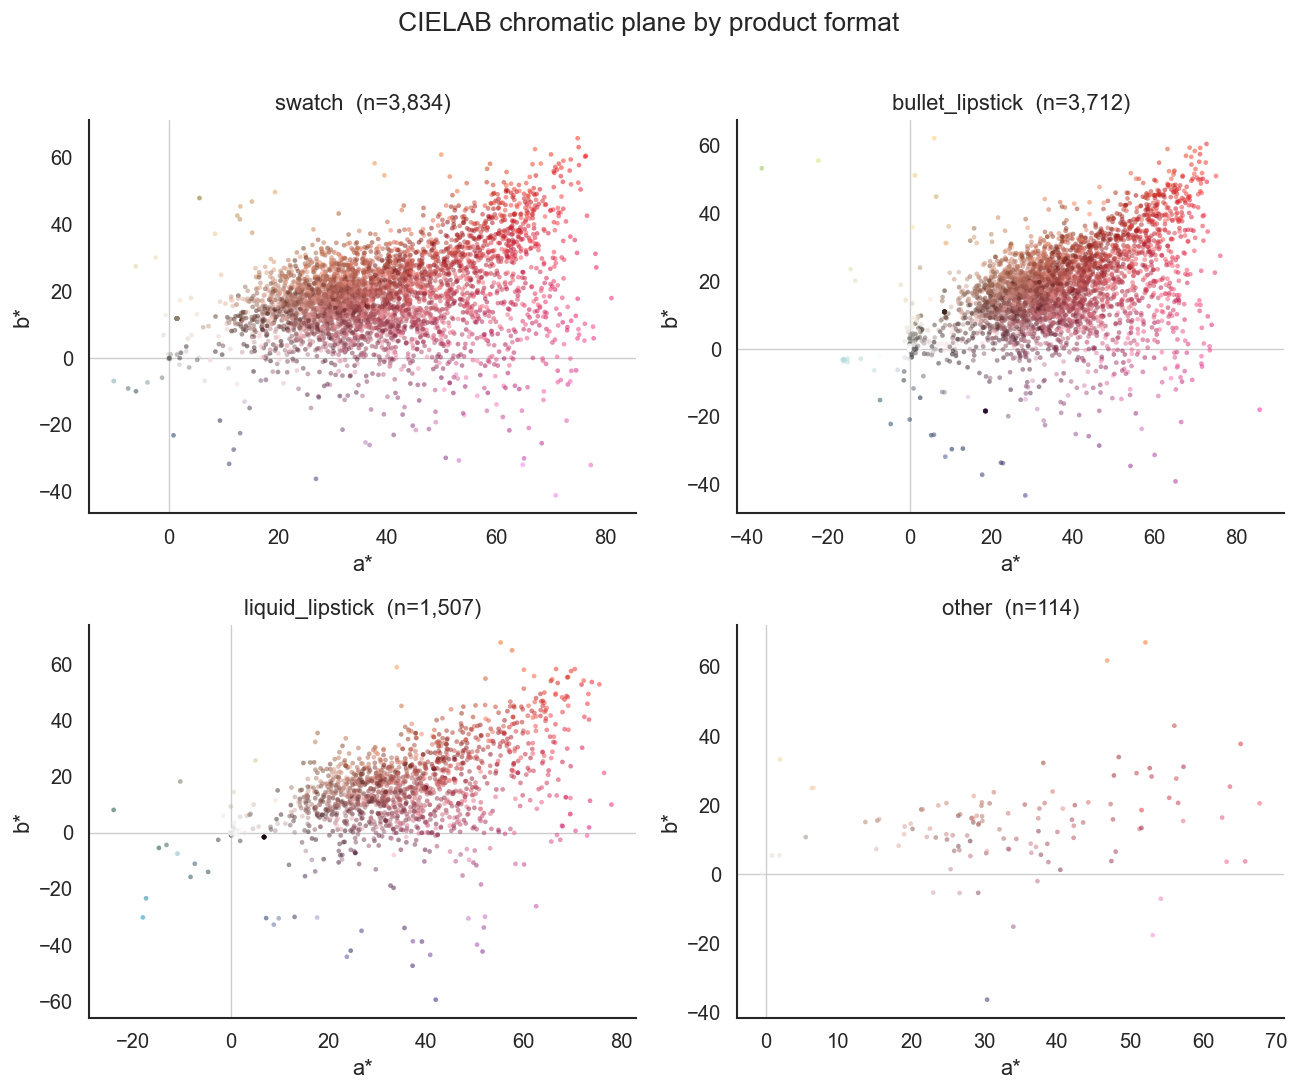

In [21]:
labels     = df['pred_label'].unique()
n_cols     = 2
n_rows     = int(np.ceil(len(labels) / n_cols))
fig, axes  = plt.subplots(n_rows, n_cols, figsize=(11, n_rows * 4.5), squeeze=False)

for ax, label in zip(axes.flat, labels):
    sub = df[df['pred_label'] == label]
    ax.scatter(sub['a'], sub['b'], c=sub['hex_color'],
               s=8, alpha=0.5, linewidths=0)
    ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
    ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
    ax.set_title(f'{label}  (n={len(sub):,})')
    ax.set_xlabel('a*')
    ax.set_ylabel('b*')
    sns.despine(ax=ax)

# Hide any unused subplots
for ax in axes.flat[len(labels):]:
    ax.set_visible(False)

fig.suptitle('CIELAB chromatic plane by product format', y=1.01)
plt.tight_layout()
plt.show()

## a\*–b\* scatter with GMM color group centroids

The 25 GMM groups are overlaid as larger circles. The centroid hex color is used to fill each marker, making it easy to see how the groups partition the color space.

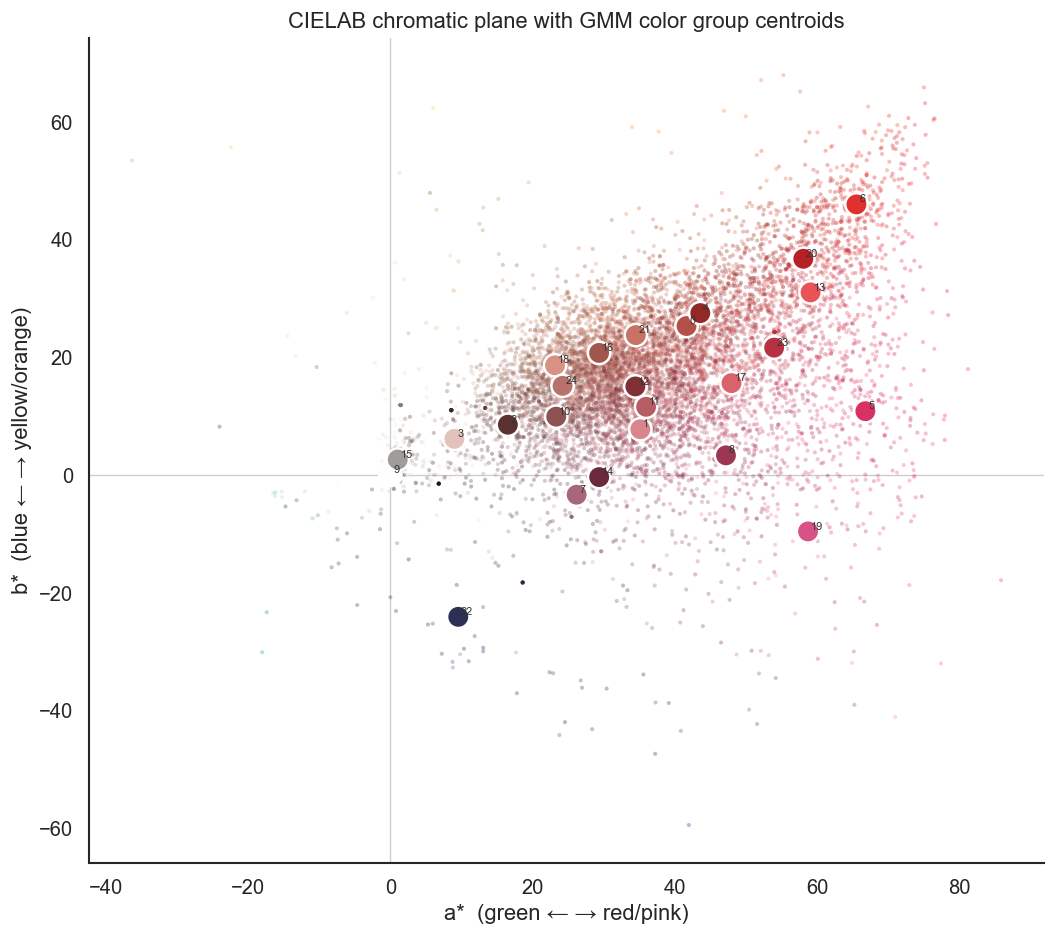

In [22]:
# Build group centroid table from the pipeline data
centroids = (
    df.groupby(['color_group', 'group_hex'])[['a', 'b']]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 8))

# All shades (small, semi-transparent)
ax.scatter(
    df['a'], df['b'],
    c=df['hex_color'],
    s=6, alpha=0.3, linewidths=0, zorder=1
)

# Group centroids (large, white border)
ax.scatter(
    centroids['a'], centroids['b'],
    c=centroids['group_hex'],
    s=180, linewidths=1.5, edgecolors='white', zorder=3
)

# Label group IDs
for _, row in centroids.iterrows():
    ax.text(row['a'] + 0.4, row['b'] + 0.4, str(int(row['color_group'])),
            fontsize=6.5, color='#333333', zorder=4)

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('CIELAB chromatic plane with GMM color group centroids')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## L\*–C\* scatter (lightness vs chroma)

Chroma C\* = √(a\*² + b\*²). High chroma = vivid; low chroma = neutral/gray. This plot separates the vivid reds/pinks from the muted nudes/browns.

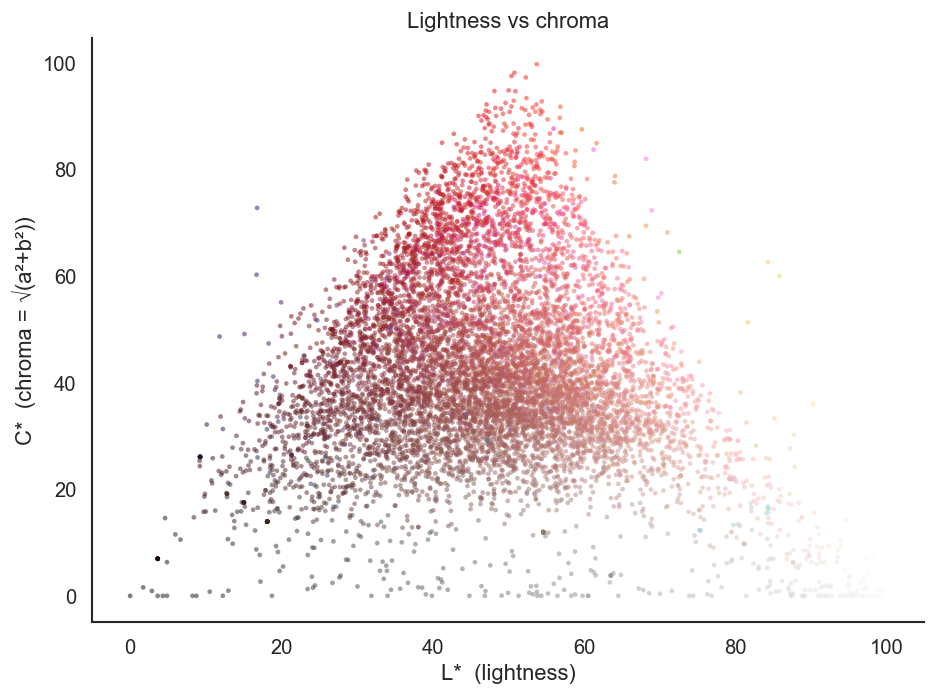

In [23]:
df['chroma'] = np.sqrt(df['a']**2 + df['b']**2)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df['L'], df['chroma'],
    c=df['hex_color'],
    s=8, alpha=0.5, linewidths=0
)

ax.set_xlabel('L*  (lightness)')
ax.set_ylabel('C*  (chroma = √(a²+b²))')
ax.set_title('Lightness vs chroma')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## a\*–b\* scatter by hue angle (undertone)

Hue angle h\* = arctan2(b\*, a\*) encodes undertone as a direction in the chromatic plane:
- **~0–30°**: cool reds / true reds
- **~30–60°**: warm reds / oranges
- **~60–90°**: orange / coral
- **~270–360°**: berries / purples / cool pinks

Points are colored by hue angle using a circular colormap (HSV). Low-chroma points (nudes, browns) still show their undertone bias even if the color looks muted.

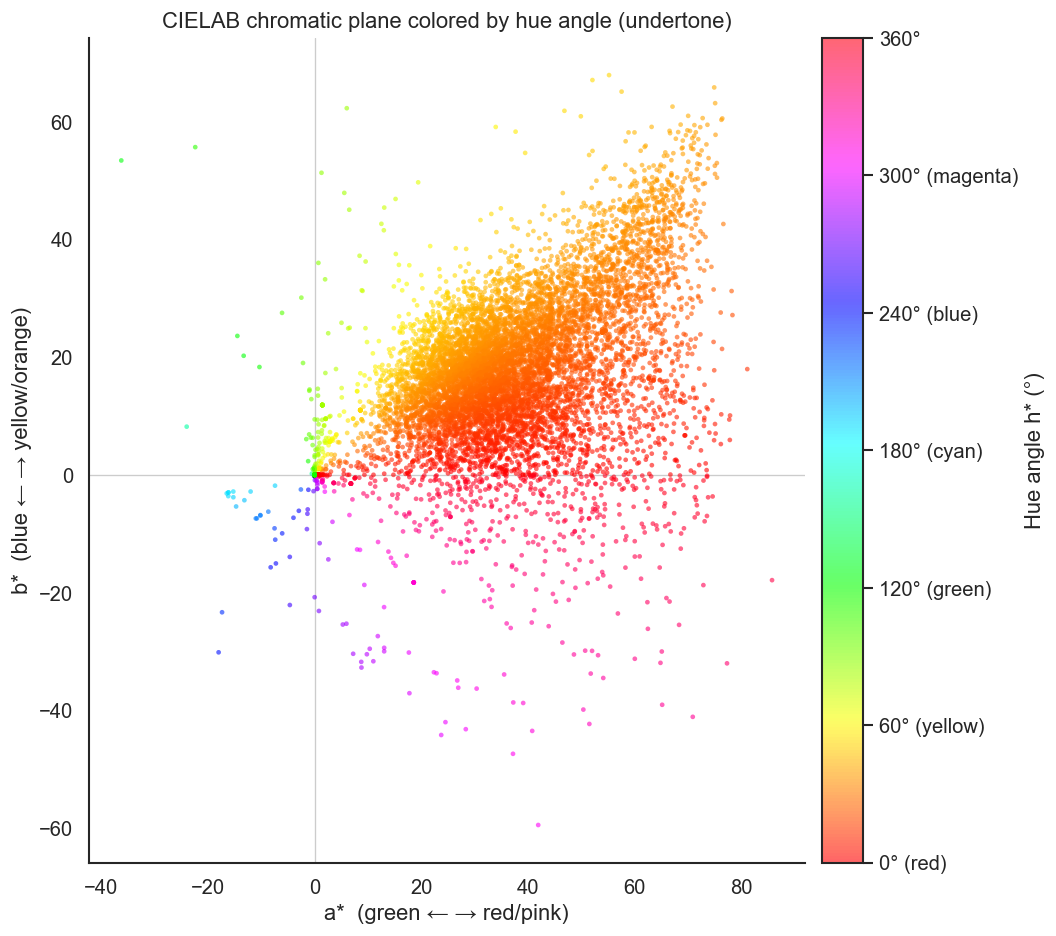

count    9167.0
mean       49.9
std        76.0
min         0.0
25%        20.9
50%        29.8
75%        38.0
max       360.0
Name: hue_angle, dtype: float64


In [24]:
df['chroma'] = np.sqrt(df['a']**2 + df['b']**2)
df['hue_angle'] = np.degrees(np.arctan2(df['b'], df['a'])) % 360

fig, ax = plt.subplots(figsize=(9, 8))

sc = ax.scatter(
    df['a'], df['b'],
    c=df['hue_angle'] / 360, cmap='hsv',
    s=8, alpha=0.6, linewidths=0
)

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label('Hue angle h* (°)')
cbar.set_ticks([0, 60/360, 120/360, 180/360, 240/360, 300/360, 1.0])
cbar.set_ticklabels(['0° (red)', '60° (yellow)', '120° (green)',
                     '180° (cyan)', '240° (blue)', '300° (magenta)', '360°'])

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('CIELAB chromatic plane colored by hue angle (undertone)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(df['hue_angle'].describe().round(1))

## Hue angle distribution and undertone classification

Hue angle thresholds for undertone:
- **Cool**: h\* < 12° (cool reds) or 270–360° (berries/mauves)
- **Neutral**: 12° ≤ h\* < 28°
- **Warm**: 28° ≤ h\* < 270° (warm reds, oranges, corals)

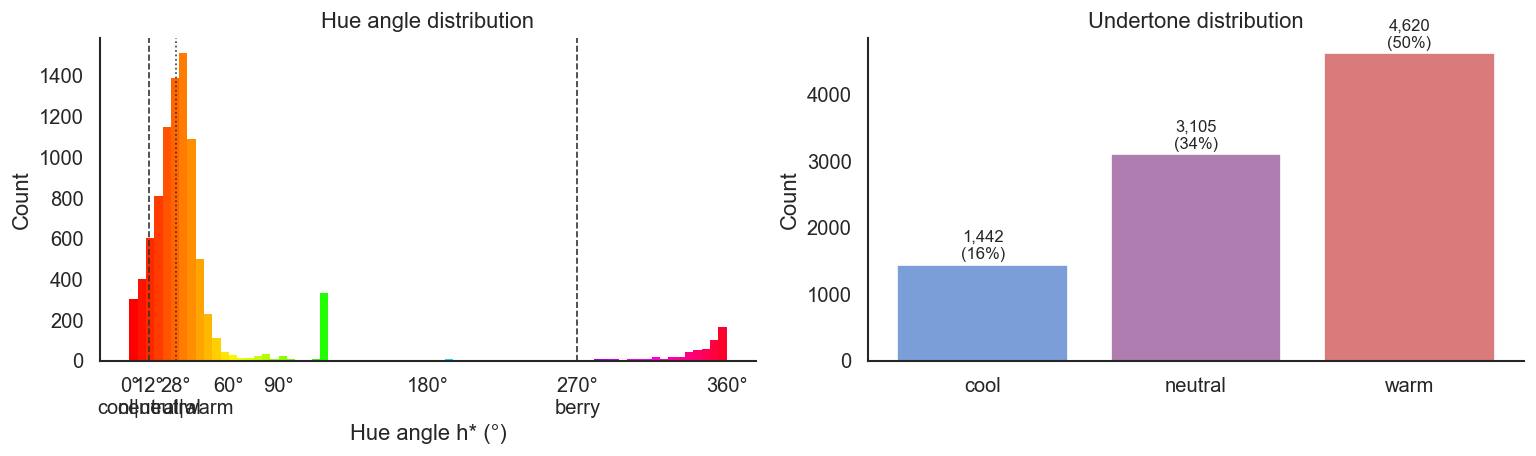

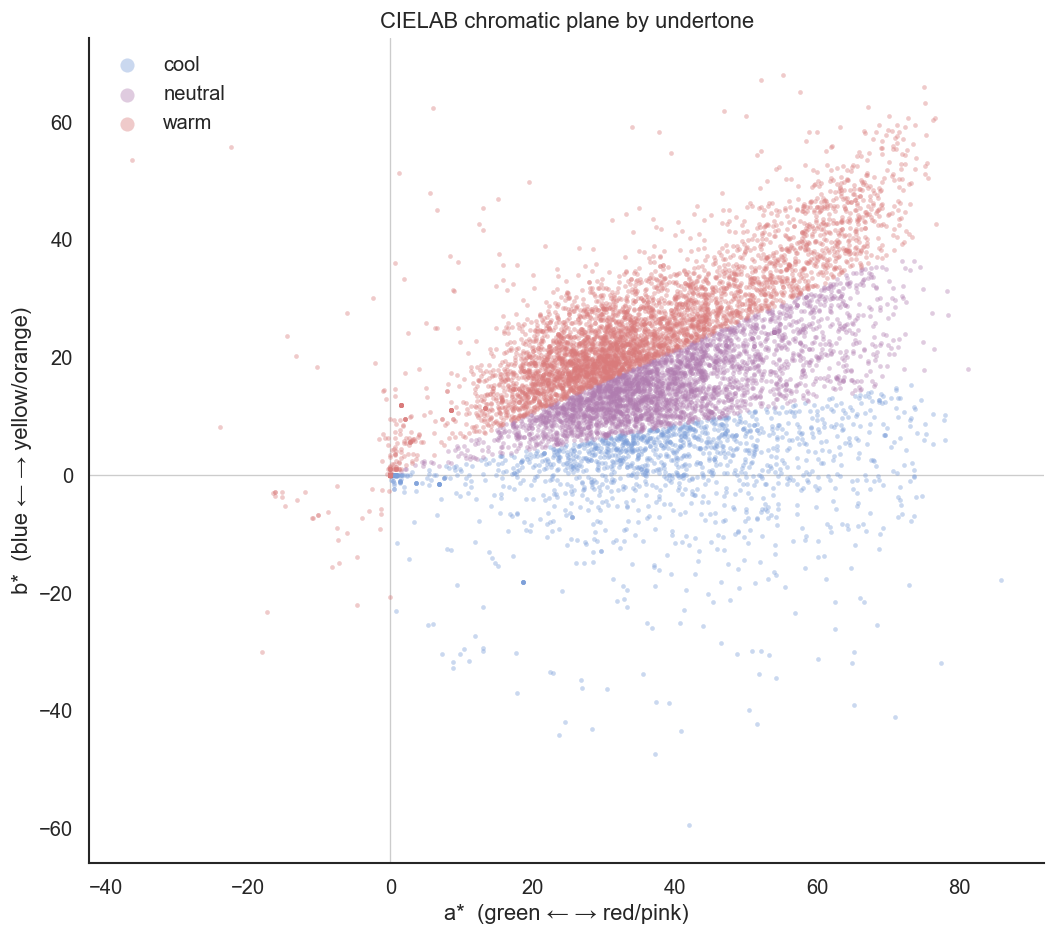

In [25]:
def classify_undertone(h):
    if h < 12 or h >= 270:
        return 'cool'
    elif h < 28:
        return 'neutral'
    else:
        return 'warm'

df['undertone'] = df['hue_angle'].apply(classify_undertone)

undertone_color = {'cool': '#7b9ed9', 'neutral': '#b07db0', 'warm': '#d97b7b'}

# ── Histogram colored by hue, with threshold lines ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
n, bins, patches = ax.hist(df['hue_angle'], bins=72, edgecolor='none')
for patch, left_edge in zip(patches, bins[:-1]):
    patch.set_facecolor(plt.cm.hsv(left_edge / 360))
ax.axvline(12,  color='#333333', lw=1, ls='--')
ax.axvline(28,  color='#333333', lw=1, ls=':')
ax.axvline(270, color='#333333', lw=1, ls='--')
ax.set_xlabel('Hue angle h* (°)')
ax.set_ylabel('Count')
ax.set_title('Hue angle distribution')
ax.set_xticks([0, 12, 28, 60, 90, 180, 270, 360])
ax.set_xticklabels(['0°', '12°\ncool|neutral', '28°\nneutral|warm',
                    '60°', '90°', '180°', '270°\nberry', '360°'])
sns.despine(ax=ax)

# ── Bar chart of undertone counts ─────────────────────────────────────────────
ax2 = axes[1]
counts = df['undertone'].value_counts().reindex(['cool', 'neutral', 'warm'])
bars = ax2.bar(counts.index, counts.values,
               color=[undertone_color[u] for u in counts.index], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
             f'{val:,}\n({val/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Count')
ax2.set_title('Undertone distribution')
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# ── a*–b* scatter colored by undertone ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))

for undertone, group in df.groupby('undertone'):
    ax.scatter(group['a'], group['b'],
               c=undertone_color[undertone], label=undertone,
               s=8, alpha=0.4, linewidths=0)

ax.axhline(0, color='#cccccc', lw=0.8, zorder=0)
ax.axvline(0, color='#cccccc', lw=0.8, zorder=0)
ax.set_xlabel('a*  (green ← → red/pink)')
ax.set_ylabel('b*  (blue ← → yellow/orange)')
ax.set_title('CIELAB chromatic plane by undertone')
ax.legend(markerscale=3, frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()